# Reprojection

This Jupyter notebook has been created to compare different features with several open source Python librairies for rasters management.

This notebook will particularly focus on reprojecting a raster object.

The following librairies will be considered :
- `rasterio`
- `rioxarray`
- `odc-geo`
- `geoutils`

In [1]:
import numpy as np

import rasterio
from rasterio.warp import calculate_default_transform, reproject, Resampling
from rasterio.plot import show

import rioxarray

import odc.geo.xr
from odc.geo.xr import xr_reproject

import geoutils as gu

import matplotlib.pyplot as plt
import matplotlib.patches as patches

In [2]:
#path to the raster object
raster_path = "../data/rasters/105005005BDEA700-visual.tif"

## Reprojection (without RPCs)

Reprojecting a raster is available in every library considered in this study.

It consists of converting a raster to a different coordinate reference system (CRS) to be correctly aligned with other data.

### • rasterio

In [3]:
ds_rasterio = rasterio.open(raster_path)

In [4]:
for key, value in ds_rasterio.meta.items():
    print(f"{key} : {value}")

driver : GTiff
dtype : uint8
nodata : None
width : 17408
height : 17408
count : 3
crs : EPSG:32627
transform : | 0.31, 0.00, 429843.75|
| 0.00,-0.31, 7085156.25|
| 0.00, 0.00, 1.00|


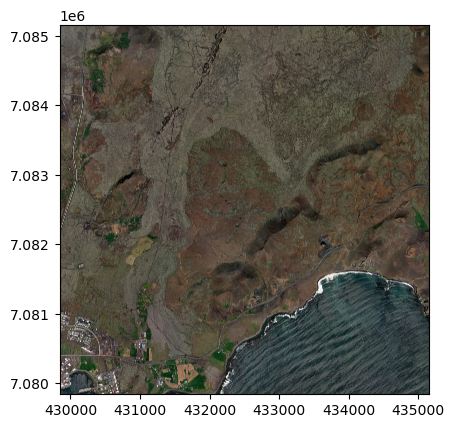

<Axes: >

In [5]:
show(ds_rasterio)

In [6]:
print(f"Dataset's CRS : {ds_rasterio.crs}")

Dataset's CRS : EPSG:32627


Our raster is currently projected in `EPSG:32627`, and we want to convert it to `EPSG:4326`.

`rasterio`'s workflow is convoluted:

- We will use the `calculate_default_transform()` function to transform bounds to target coordinate system, calculate resolution, and returns destination transform and dimensions.
- We will then use `reproject()` to reproject our raster to the new CRS. The reprojection with `rasterio` is performed eagerly. Since it works on numpy arrays, the reading is done instantly, and reprojecting triggers calculations and load data into memory.

In `rasterio`, the metadata management is not an easy task: we first need to copy the metadata of our input raster, and pass them as an argument during the reprojection, so the output raster has its own metadata, which is not really convenient.

In [ ]:
dst_crs = "EPSG:4326" #targeted CRS

dst_path = "../outputs/rasterio_reproj.tif"

with rasterio.open(raster_path) as src:
    transform, width, height = calculate_default_transform(
        src.crs, dst_crs, src.width, src.height, *src.bounds)
    kwargs = src.meta.copy() #copy metadata
    kwargs.update({
        'crs': dst_crs,
        'transform': transform,
        'width': width,
        'height': height
    })

    with rasterio.open(dst_path, 'w', **kwargs) as dst:
        for i in range(1, src.count + 1): #band-by-band reprojection
            reproject(
                source=rasterio.band(src, i),
                destination=rasterio.band(dst, i),
                src_transform=src.transform,
                src_crs=src.crs,
                dst_transform=transform,
                dst_crs=dst_crs,
                resampling=Resampling.nearest)

We can then plot our new image and its associated metadata:

driver : GTiff
dtype : uint8
nodata : None
width : 22678
height : 10003
count : 3
crs : EPSG:4326
transform : | 0.00, 0.00,-22.43|
| 0.00,-0.00, 63.89|
| 0.00, 0.00, 1.00|


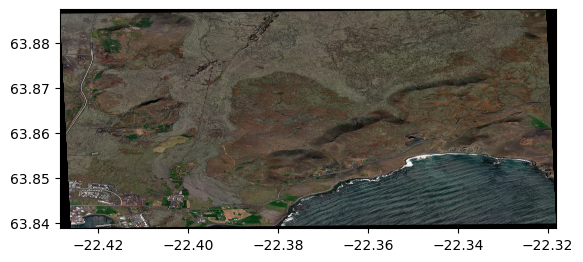

In [8]:
with rasterio.open(dst_path) as rasterio_reproj:
    for key, value in rasterio_reproj.meta.items():
        print(f"{key} : {value}")
    show(rasterio_reproj)

### • rioxarray

With rioxarray, we will use the [`.reproject()` function](https://corteva.github.io/rioxarray/stable/rioxarray.html#rioxarray.raster_array.RasterArray.reproject):

In [3]:
da_rxr = rioxarray.open_rasterio(raster_path, chunks={'x' : 2048, 'y' : 2048})

Here are the metadata of our dataset:

In [4]:
print(f"""
Dimensions : {da_rxr.dims}
Number of band(s) : {da_rxr.rio.count}
Data type : {da_rxr.dtype}
Shape : {da_rxr.shape}
Size : {da_rxr.rio.height} rows x {da_rxr.rio.width} columns
CRS : {da_rxr.rio.crs}
Resolution : {da_rxr.rio.resolution()}
Bounds : {da_rxr.rio.bounds()}
Transform : {da_rxr.rio.transform()}
Attributes : {da_rxr.attrs}
""")


Dimensions : ('band', 'y', 'x')
Number of band(s) : 3
Data type : uint8
Shape : (3, 17408, 17408)
Size : 17408 rows x 17408 columns
CRS : EPSG:32627
Resolution : (0.30517578125, -0.30517578125)
Bounds : (429843.75, 7079843.75, 435156.25, 7085156.25)
Transform : | 0.31, 0.00, 429843.75|
| 0.00,-0.31, 7085156.25|
| 0.00, 0.00, 1.00|
Attributes : {'AREA_OR_POINT': 'Area', 'STATISTICS_APPROXIMATE': 'YES', 'STATISTICS_MAXIMUM': 255, 'STATISTICS_MEAN': 78.752000432524, 'STATISTICS_MINIMUM': 0, 'STATISTICS_STDDEV': 19.373427391787, 'STATISTICS_VALID_PERCENT': 100, 'scale_factor': 1.0, 'add_offset': 0.0}



`rioxarray` greatly simplifies the metadata management compared to rasterio.

The `.reproject()` function is more straightforward than in `rasterio`, we just need to specify the targeted CRS.

Since we have opened our raster with chunks, data are lazy and stored as dask tasks. When calling the reproject function, it will create a `dask` graph but calculations are only executed when using `.compute()`, or when saving the array to a new file.

In [6]:
dst_crs = "EPSG:4326" #targeted CRS

rxr_reproj = da_rxr.rio.reproject(dst_crs)

We can now verify the new CRS and image:

In [12]:
print(f"""
Dimensions : {rxr_reproj.dims}
Number of band(s) : {rxr_reproj.rio.count}
Data type : {rxr_reproj.dtype}
Shape : {rxr_reproj.shape}
Size : {rxr_reproj.rio.height} rows x {rxr_reproj.rio.width} columns
CRS : {rxr_reproj.rio.crs}
Resolution : {rxr_reproj.rio.resolution()}
Bounds : {rxr_reproj.rio.bounds()}
Transform : {rxr_reproj.rio.transform()}
Attributes : {rxr_reproj.attrs}
""")


Dimensions : ('band', 'y', 'x')
Number of band(s) : 3
Data type : uint8
Shape : (3, 10003, 22678)
Size : 10003 rows x 22678 columns
CRS : EPSG:4326
Resolution : (4.8673433040755955e-06, -4.8673433040755955e-06)
Bounds : (-22.428632022553476, 63.83887638617753, -22.318250411103648, 63.8875644212482)
Transform : | 0.00, 0.00,-22.43|
| 0.00,-0.00, 63.89|
| 0.00, 0.00, 1.00|
Attributes : {'AREA_OR_POINT': 'Area', 'STATISTICS_APPROXIMATE': 'YES', 'STATISTICS_MAXIMUM': 255, 'STATISTICS_MEAN': 78.752000432524, 'STATISTICS_MINIMUM': 0, 'STATISTICS_STDDEV': 19.373427391787, 'STATISTICS_VALID_PERCENT': 100, 'scale_factor': 1.0, 'add_offset': 0.0, '_FillValue': 255}



And we can plot the new image:

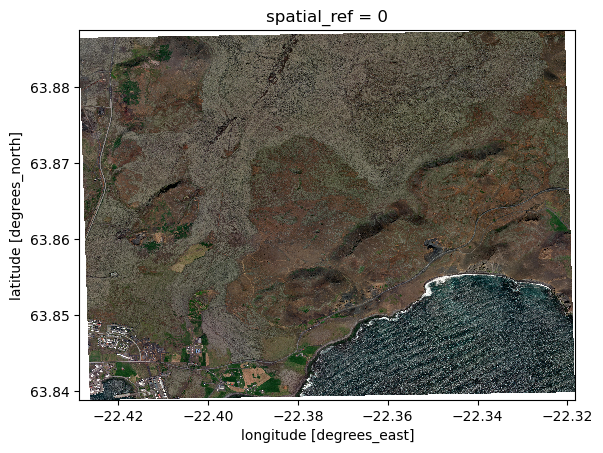

In [15]:
rxr_reproj.plot.imshow()

### • odc-geo

With `odc-geo`, we will use the [`.xr_reproject()`](https://odc-geo.readthedocs.io/en/latest/_api/odc.geo.xr.xr_reproject.html) function to reproject our raster

In [7]:
ds_odcgeo = rioxarray.open_rasterio(raster_path, chunks={'x' : 2048, 'y' : 2048})

We can simply pass the image and the desired CRS as arguments.

`odc-geo` has implemented a lazy version of the reprojection, called `xr_reproject`. This function will create new dask tasks for reprojection but will not trigger instant calculations.

In [8]:
dst_crs = "EPSG:4326"

odcgeo_reproj = xr_reproject(ds_odcgeo, dst_crs)

Our new raster has now the expected CRS:

In [19]:
print(odcgeo_reproj.rio.crs)

EPSG:4326


Let's plot the newly created raster (the computation should be triggered by the plot and this may take a bit of time):

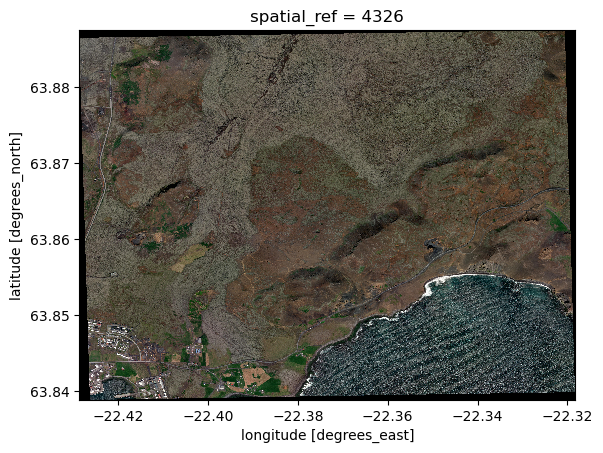

In [20]:
odcgeo_reproj.plot.imshow()

### • geoutils

In geoutils, we will use the [`.reproject()`](https://geoutils.readthedocs.io/en/stable/gen_modules/geoutils.Raster.reproject.html#geoutils.Raster.reproject) function:

In [21]:
ds_geoutils = gu.Raster(raster_path)

In [22]:
print(f"Dataset's CRS : {ds_geoutils.crs}")

Dataset's CRS : EPSG:32627


To reproject, we can simply pass the targeted CRS as an argument.

When using the `.reproject` function, data will be loaded instantly, will do the reprojection using memory and will return the newly created object with the reprojection result.

In [23]:
gu_reprojected = ds_geoutils.reproject(crs=dst_crs)

c:\Users\cbernaert\AppData\Local\anaconda3\envs\open_source_rasters_comparison\Lib\site-packages\geoutils\raster\_geotransformations.py:117: UserWarning: For reprojection, nodata must be set. Setting default nodata to 255. You may set a different nodata with `nodata`.
  warnings.warn(


However, `geoutils` will release soon an `xarray` accessor and with it a lazy version of its reprojection, leveraging `dask` as seen in the documentation:
 > reprojection can be computed out-of-memory in multiprocessing, by passing a MultiprocConfig object. The reprojected raster is written to disk under the path specified in the configuration.

In [24]:
print(f"Reprojected Dataset's CRS : {gu_reprojected.crs}")

Reprojected Dataset's CRS : EPSG:4326


We can finally plot the new raster:

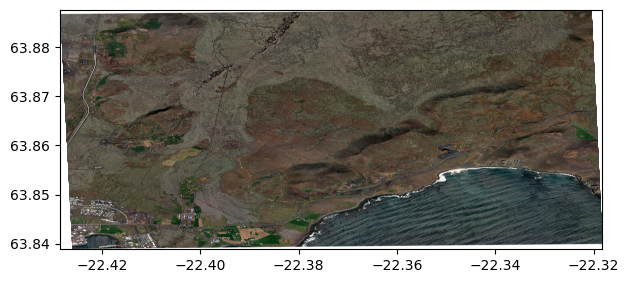

In [25]:
gu_reprojected.plot()

## Reproject match

Reproject match is a feature only available in `rioxarray` and `geoutils`.

This feature is useful to reproject an image to match the exact projection, resolution and grid of another raster without extracting these information by hand and repassing them to the cclassic reprojection fucntion.

In this example we will reproject a DEM (Digital Elevation Model) on a satellite image with an different CRS.

### • rioxarray

With `rioxarray`, we can use the [`.reproject_match()` function](https://corteva.github.io/rioxarray/stable/examples/reproject_match.html):

In this example we will reproject a DEM imagery of Sardinia with a wrong CRS to align it with another raster that has the correct one.

In [2]:
#path of the sat image
raster_path = "../data/rasters/T32TNK_20251113T101159_TCI.jp2"

In [3]:
#path of the dem with incorrect CRS
dem_wrong_crs_path = "../data/rasters/sard1.tif"

In [4]:
da_rxr_valid = rioxarray.open_rasterio(raster_path)

da_rxr_dem_invalid = rioxarray.open_rasterio(dem_wrong_crs_path)

In [5]:
print(f"""
VALID RASTER ATTRIBUTES\n
shape: {da_rxr_valid.rio.shape}
resolution: {da_rxr_valid.rio.resolution()}
bounds: {da_rxr_valid.rio.bounds()}
CRS: {da_rxr_valid.rio.crs}
""")


VALID RASTER ATTRIBUTES

shape: (10980, 10980)
resolution: (10.0, -10.0)
bounds: (499980.0, 4390200.0, 609780.0, 4500000.0)
CRS: EPSG:32632



Here is the reference raster that we want to match:

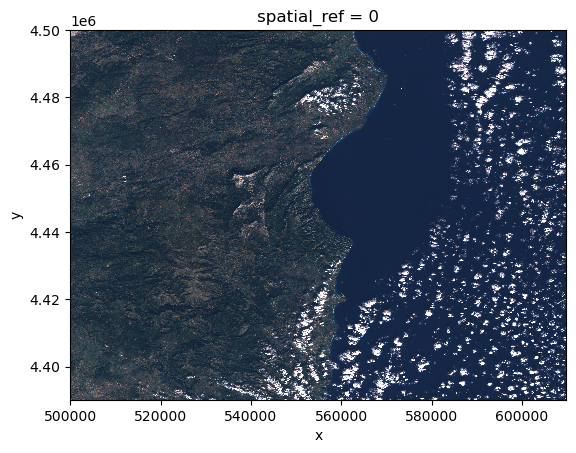

In [5]:
da_rxr_valid.plot.imshow()
plt.show()

In [6]:
print(f"""
DEM WRONG CRS ATTRIBUTES\n
shape: {da_rxr_dem_invalid.rio.shape}
resolution: {da_rxr_dem_invalid.rio.resolution()}
bounds: {da_rxr_dem_invalid.rio.bounds()}
CRS: {da_rxr_dem_invalid.rio.crs} <-- to be changed
""")


DEM WRONG CRS ATTRIBUTES

shape: (9835, 5761)
resolution: (25.0, -25.0)
bounds: (4162400.0, 1754125.0, 4306425.0, 2000000.0)
CRS: IGNF:ETRS89LAEA <-- to be changed



And we can plot the DEM with incorrect CRS:

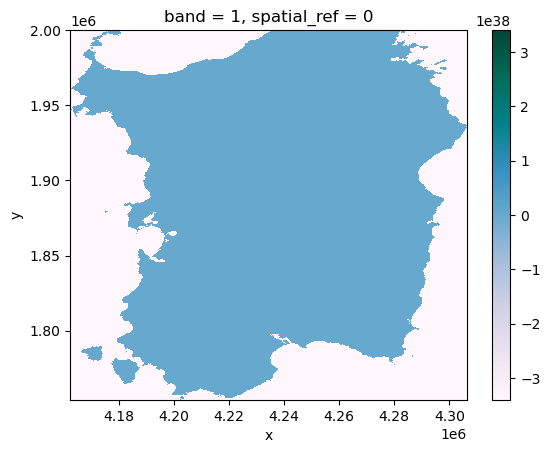

In [110]:
da_rxr_dem_invalid.sel(band=1).plot.imshow(cmap="PuBuGn")

DEM CRS is `IGNF:ETRS89UTM32` and we want to align it onto the satellite image one: `EPSG:32632` (CRS of the reference raster)

We can use the `reproject_match()` function, we just have to pass the raster correctly projected as an argument:

In [7]:
rxr_repr_match = da_rxr_dem_invalid.rio.reproject_match(da_rxr_valid)

If we check the newly projected raster, its CRS has been changed accordingly to our referenced raster:

In [8]:
print(f"""
REPROJECTED RASTER ATTRIBUTES\n
shape: {rxr_repr_match.rio.shape}
resolution: {rxr_repr_match.rio.resolution()}
bounds: {rxr_repr_match.rio.bounds()}
CRS: {rxr_repr_match.rio.crs}
""")


REPROJECTED RASTER ATTRIBUTES

shape: (10980, 10980)
resolution: (10.0, -10.0)
bounds: (499980.0, 4390200.0, 609780.0, 4500000.0)
CRS: EPSG:32632



We can now plot our reference raster with the reprojected DEM on top, as follows:

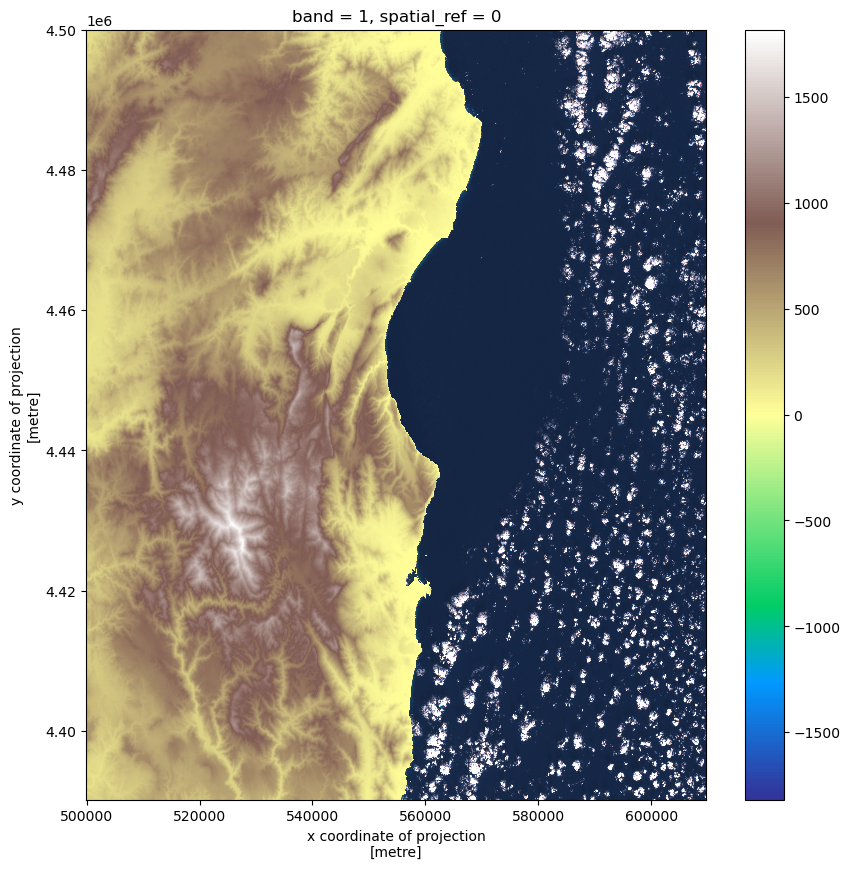

In [13]:
fig,ax = plt.subplots(figsize=(10, 10))

da_rxr_valid.plot.imshow(ax=ax)

rxr_repr_match.where(rxr_repr_match!=rxr_repr_match.rio.nodata).sel(band=1).plot.imshow(ax=ax, cmap="terrain", add_colorbar=True)

plt.show()

### • geoutils

To reproject match using `geoutils`, we will reuse the [`.reproject()`](https://geoutils.readthedocs.io/en/stable/gen_modules/geoutils.Raster.reproject.html) function already seen previously, but this time we will pass the argument `ref=` with another raster, so our image will be reprojected according to the resolution, bounds and CRS of this referenced raster.


In [14]:
gu_rast_valid = gu.Raster(raster_path)

gu_rast_invalid = gu.Raster(dem_wrong_crs_path)

In [15]:
gu_rast_valid.info()

Driver:               JP2OpenJPEG 
Opened from file:     ../data/rasters/T32TNK_20251113T101159_TCI.jp2 
Filename:             ../data/rasters/T32TNK_20251113T101159_TCI.jp2 
Loaded?               False 
Modified since load?  False 
Grid size:            10980, 10980
Number of bands:      3
Data types:           uint8
Coordinate system:    ['EPSG:32632']
Nodata value:         None
Pixel interpretation: None
Pixel size:           10.0, 10.0
Upper left corner:    499980.0, 4500000.0
Lower right corner:   609780.0, 4390200.0



In [16]:
gu_rast_invalid.info()

Driver:               GTiff 
Opened from file:     ../data/rasters/sard1.tif 
Filename:             ../data/rasters/sard1.tif 
Loaded?               False 
Modified since load?  False 
Grid size:            5761, 9835
Number of bands:      1
Data types:           float32
Coordinate system:    ['IGNF:ETRS89LAEA']
Nodata value:         -3.4028234663852886e+38
Pixel interpretation: Area
Pixel size:           25.0, 25.0
Upper left corner:    4162400.0, 2000000.0
Lower right corner:   4306425.0, 1754125.0



As previously, we can reuse the `reproject()` function, but this time we pass our valid raster as an argument:

In [17]:
gu_reproj = gu_rast_invalid.reproject(gu_rast_valid)

The reprojected raster has now the right CRS :

In [18]:
gu_reproj.info()

Driver:               None 
Opened from file:     None 
Filename:             None 
Loaded?               True 
Modified since load?  True 
Grid size:            10980, 10980
Number of bands:      1
Data types:           float32
Coordinate system:    ['EPSG:32632']
Nodata value:         -3.4028234663852886e+38
Pixel interpretation: Area
Pixel size:           10.0, 10.0
Upper left corner:    499980.0, 4500000.0
Lower right corner:   609780.0, 4390200.0



Finally, we can plot our reprojected DEM on top of our reference raster, as follows:

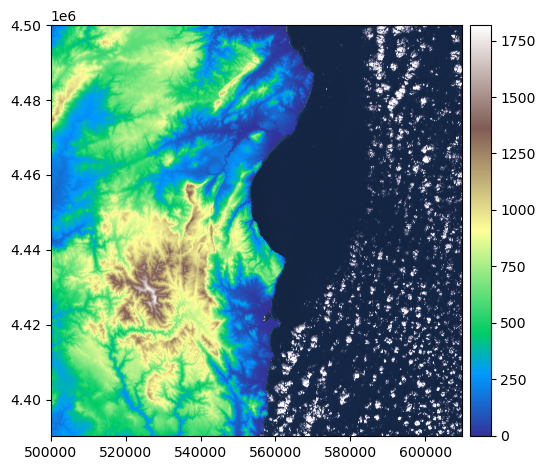

In [20]:
gu_rast_valid.plot()
gu_reproj.plot(cmap="terrain")